In [35]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import scipy.sparse as sparse

# print(plt.style.available) # uncomment to print all styles
import seaborn as sns
sns.set(font_scale=2)
plt.rcParams['figure.figsize'] = (10,10)
%matplotlib inline

<img src="sparse.png" alt="Sparse" style="width: 300px;"/>

## Create a Sparse Matrix in COO

In [5]:
data = [1.9, -5.2, 4.4, 5.8, 3.6, 7.2, 2.7]
i    = [  0,    0,    2,   2,   2,   3,   3]
j    = [  1,    3,    0,   1,   2,   2,   3]
A = sparse.coo_matrix((data, (i, j)))

print(A)
print(A.todense())

A = A.tocsr()
print(A.data)
print(A.indptr)
print(A.indices)

<COOrdinate sparse matrix of dtype 'float64'
	with 7 stored elements and shape (4, 4)>
  Coords	Values
  (0, 1)	1.9
  (0, 3)	-5.2
  (2, 0)	4.4
  (2, 1)	5.8
  (2, 2)	3.6
  (3, 2)	7.2
  (3, 3)	2.7
[[ 0.   1.9  0.  -5.2]
 [ 0.   0.   0.   0. ]
 [ 4.4  5.8  3.6  0. ]
 [ 0.   0.   7.2  2.7]]
[ 1.9 -5.2  4.4  5.8  3.6  7.2  2.7]
[0 2 2 5 7]
[1 3 0 1 2 2 3]


In [6]:
def bmatrix(a):
    """Returns a LaTeX bmatrix

    :a: numpy array
    :returns: LaTeX bmatrix as a string
    """
    if len(a.shape) > 2:
        raise ValueError('bmatrix can at most display two dimensions')
    lines = str(a).replace('[', '').replace(']', '').splitlines()
    rv = [r'\begin{bmatrix}']
    rv += ['  ' + ' & '.join(l.split()) + r'\\' for l in lines]
    rv +=  [r'\end{bmatrix}']
    return '\n'.join(rv)

In [7]:
print(bmatrix(A.indices))

\begin{bmatrix}
  1 & 3 & 0 & 1 & 2 & 2 & 3\\
\end{bmatrix}


$$data = 
\begin{bmatrix}
  1.9 & -5.2 & 4.4 & 5.8 & 3.6 & 7.2 & 2.7\\
\end{bmatrix}$$

$$rowptr = 
\begin{bmatrix}
  0 & 2 & 2 & 5 & 7\\
\end{bmatrix}
$$

$$col = 
\begin{bmatrix}
  1 & 3 & 0 & 1 & 2 & 2 & 3\\
\end{bmatrix}
$$

$$A  = \begin{bmatrix}
  0. & 1.9 & 0. & -5.2\\
  0. & 0. & 0. & 0.\\
  4.4 & 5.8 & 3.6 & 0.\\
  0. & 0. & 7.2 & 2.7\\
\end{bmatrix}$$

In [8]:
data = [-5.2, 1.9, 0.3, 9.1, 4.4, 5.8, 3.6, 7.2, 2.7]
i    = [   0,   0,   1,   1,   2,   2,   2,   3,   3]
j    = [   3,   1,   0,   2,   0,   1,   2,   2,   3]
A = sparse.coo_matrix((data, (i, j)))
print(A.todense())

[[ 0.   1.9  0.  -5.2]
 [ 0.3  0.   9.1  0. ]
 [ 4.4  5.8  3.6  0. ]
 [ 0.   0.   7.2  2.7]]


In [9]:
print(A.data)
print(A.data.dtype, 'Length: ', len(A.data))
print('-')
print(A.row)
print(A.row.dtype, 'Length: ', len(A.row))
print('-')
print(A.col)
print(A.col.dtype, 'Length: ', len(A.row))

[-5.2  1.9  0.3  9.1  4.4  5.8  3.6  7.2  2.7]
float64 Length:  9
-
[0 0 1 1 2 2 2 3 3]
int32 Length:  9
-
[3 1 0 2 0 1 2 2 3]
int32 Length:  9


## Convert to CSR

In [10]:
A = A.tocsr()
print(A)
print(A.todense())

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (4, 4)>
  Coords	Values
  (0, 1)	1.9
  (0, 3)	-5.2
  (1, 0)	0.3
  (1, 2)	9.1
  (2, 0)	4.4
  (2, 1)	5.8
  (2, 2)	3.6
  (3, 2)	7.2
  (3, 3)	2.7
[[ 0.   1.9  0.  -5.2]
 [ 0.3  0.   9.1  0. ]
 [ 4.4  5.8  3.6  0. ]
 [ 0.   0.   7.2  2.7]]


In [11]:
print(A.data)
print(A.data.dtype, 'Length: ', len(A.data))
print('-')
print(A.indptr)
print(A.indptr.dtype, 'Length: ', len(A.indptr))
print('-')
print(A.indices)
print(A.indices.dtype, 'Length: ', len(A.indices))

[ 1.9 -5.2  0.3  9.1  4.4  5.8  3.6  7.2  2.7]
float64 Length:  9
-
[0 2 4 7 9]
int32 Length:  5
-
[1 3 0 2 0 1 2 2 3]
int32 Length:  9


## Try some timings: small, `Harvard500`

In [12]:
import scipy.io as sio
d = sio.loadmat('Harvard500.mat')
A = d['Problem'][0][0][2].tocsr()

In [13]:
A

<Compressed Sparse Row sparse array of dtype 'float64'
	with 2636 stored elements and shape (500, 500)>

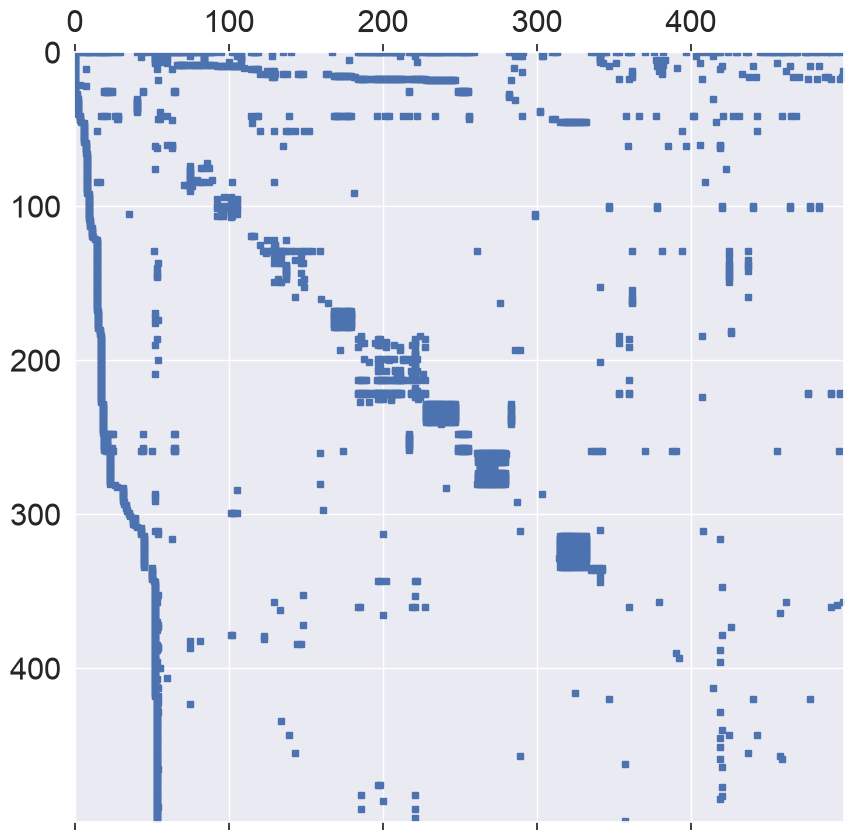

In [14]:
plt.figure(figsize=(10,10))
plt.spy(A, ms=5)

In [15]:
A.shape[0]

500

In [16]:
v = np.random.rand(A.shape[0])
w = np.random.rand(A.shape[0])

In [17]:
%timeit v = A * w

13.9 μs ± 102 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [18]:
Adense = A.todense()

In [19]:
%timeit v = Adense.dot(w)

4.76 μs ± 36.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Medium `wb-cs-stanford`

In [20]:
d = sio.loadmat('wb-cs-stanford.mat')
A = d['Problem'][0][0][2].tocsr()

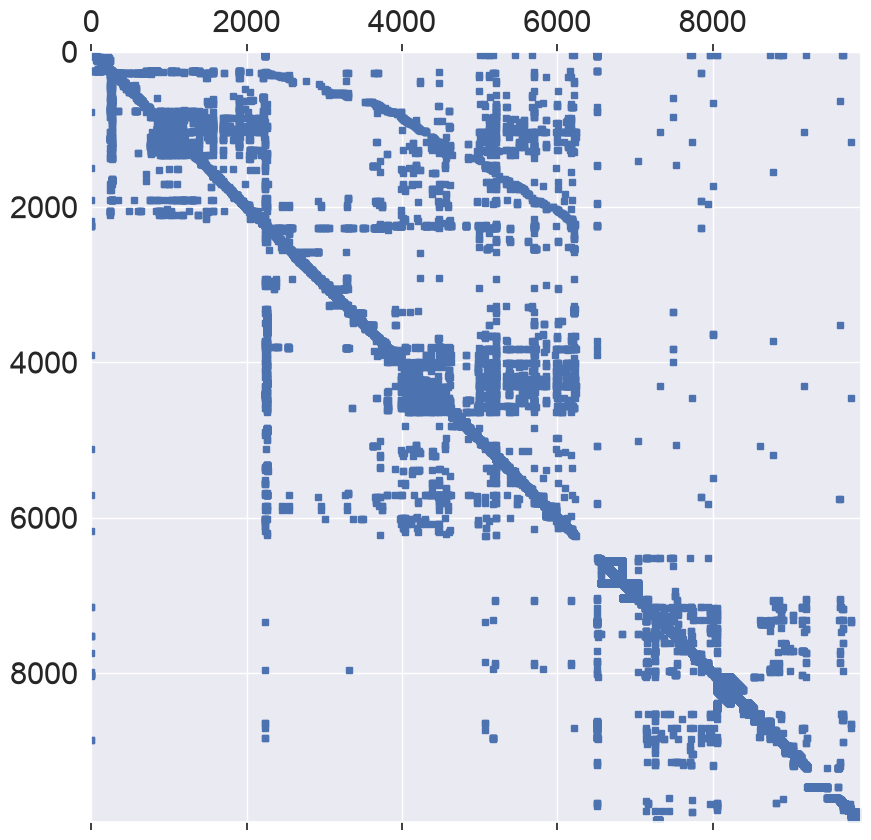

In [21]:
plt.figure(figsize=(10,10))
plt.spy(A, ms=5)

In [22]:
A

<Compressed Sparse Row sparse array of dtype 'float64'
	with 36854 stored elements and shape (9914, 9914)>

In [23]:
v = np.random.rand(A.shape[0])
w = np.random.rand(A.shape[0])

In [24]:
%timeit v = A * w

66.9 μs ± 1.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
Adense = A.todense()

In [26]:
%timeit v = Adense.dot(w)

5.97 ms ± 149 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Large `email-Enron`

In [27]:
d = sio.loadmat('email-Enron.mat')
A = d['Problem'][0][0][2].tocsr()

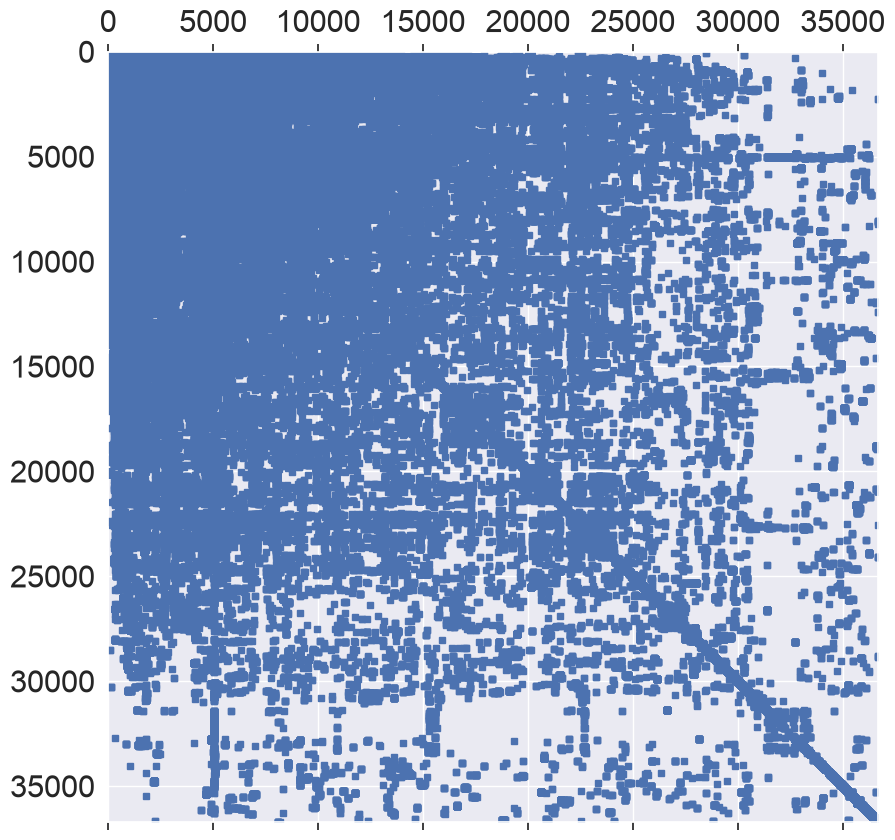

In [28]:
plt.figure(figsize=(10,10))
plt.spy(A, ms=5)

In [29]:
A

<Compressed Sparse Row sparse array of dtype 'float64'
	with 367662 stored elements and shape (36692, 36692)>

In [30]:
v = np.random.rand(A.shape[0])
w = np.random.rand(A.shape[0])

In [31]:
%timeit v = A * w

642 μs ± 12.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [32]:
Adense = A.todense()

In [33]:
%timeit v = Adense.dot(w)

The slowest run took 6.88 times longer than the fastest. This could mean that an intermediate result is being cached.
166 ms ± 166 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
